In [1]:
# Customer Profile and Group Comparability

## Business Question

#Who are Vanguard's customers, and are the Test and Control groups comparable?

## Objective

#The purpose of this analysis is to understand the characteristics of clients included in Vanguard's A/B experiment and determine whether the Test and Control groups are reasonably comparable.

#Before evaluating whether the redesigned digital experience performed better, we need to check whether differences between the groups already existed in client characteristics such as age, tenure, account balance, number of accounts, calls, logons, and gender.

#This analysis focuses on client-level characteristics because `client_id` is the experimental unit.

In [4]:
import pandas as pd
import os

print(os.getcwd())

/Users/jannoelvero/Documents/Ironhack/week_6/Week_6_Project


In [5]:
import pandas as pd

demo_df = pd.read_csv(
    "data/raw/df_final_demo.txt"
)

experiment_df = pd.read_csv(
    "data/raw/df_final_experiment_clients (1).txt"
)

In [6]:
print("Client Profiles:", demo_df.shape)
print("Experiment Roster:", experiment_df.shape)

Client Profiles: (70609, 9)
Experiment Roster: (70609, 2)


In [7]:
clients_df = demo_df.merge(
    experiment_df,
    on="client_id",
    how="inner"
)

print("Merged clients:", clients_df.shape)

Merged clients: (70609, 10)


In [9]:
ab_clients_df = clients_df[
    clients_df["Variation"].isin(["Test", "Control"])
].copy()

print("A/B experiment clients:", ab_clients_df.shape)

A/B experiment clients: (50500, 10)


In [12]:
#Group size verification
ab_clients_df["Variation"].value_counts()

Variation
Test       26968
Control    23532
Name: count, dtype: int64

In [11]:
ab_clients_df["Variation"].value_counts(
    normalize=True
) * 100

Variation
Test       53.40198
Control    46.59802
Name: proportion, dtype: float64

In [13]:
###Who are Vanguard's experimental customers?
#Describe Vanguard's experimental customers
#overall profile of clients participating in the experiment before separating Test and Control.

In [14]:
ab_clients_df[
    [
        "clnt_age",
        "clnt_tenure_yr",
        "clnt_tenure_mnth",
        "num_accts",
        "bal",
        "calls_6_mnth",
        "logons_6_mnth"
    ]
].describe()

,clnt_age,clnt_tenure_yr,clnt_tenure_mnth,num_accts,bal,calls_6_mnth,logons_6_mnth
count,50487.000000,50488.000000,50488.000000,50488.000000,5.048800e+04,50488.000000,50488.000000
mean,47.319795,12.031730,150.415485,2.254575,1.495147e+05,3.093289,6.131873
std,15.518616,6.860282,81.944830,0.533671,3.020364e+05,2.187991,2.175423
min,17.000000,2.000000,33.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,33.500000,6.000000,82.000000,2.000000,3.987841e+04,1.000000,4.000000
50%,48.000000,11.000000,136.000000,2.000000,6.573360e+04,3.000000,6.000000
75%,59.500000,16.000000,192.000000,2.000000,1.399565e+05,5.000000,8.000000
max,96.000000,55.000000,669.000000,7.000000,1.632004e+07,6.000000,9.000000


In [15]:
#check gender
ab_clients_df["gendr"].value_counts(
    dropna=False
)

gendr
U      17280
M      16947
F      16259
NaN       12
X          2
Name: count, dtype: int64

In [16]:
ab_clients_df["gendr"].value_counts(
    dropna=False,
    normalize=True
) * 100

gendr
U      34.217822
M      33.558416
F      32.196040
NaN     0.023762
X       0.003960
Name: proportion, dtype: float64

In [19]:
#check missing values in the A/B population
ab_clients_df.isnull().sum()

client_id            0
clnt_tenure_yr      12
clnt_tenure_mnth    12
clnt_age            13
gendr               12
num_accts           12
bal                 12
calls_6_mnth        12
logons_6_mnth       12
Variation            0
dtype: int64

In [20]:
### Missing Values in the Experimental Population

#The A/B experiment dataset contains very limited missing demographic information. Most client characteristics contain 12 missing observations, while `clnt_age` contains 13 missing observations among 50,500 experimental clients.

#No experimental assignments are missing because the dataset has already been restricted to Test and Control participants.

#Given the extremely small proportion of missing values, no imputation will be performed. Analyses requiring these variables will use the available observations, and missing records will be excluded only where necessary for the specific calculation or statistical test.

In [21]:
ab_clients_df[
    [
        "clnt_age",
        "clnt_tenure_yr",
        "clnt_tenure_mnth",
        "num_accts",
        "bal",
        "calls_6_mnth",
        "logons_6_mnth"
    ]
].describe()

,clnt_age,clnt_tenure_yr,clnt_tenure_mnth,num_accts,bal,calls_6_mnth,logons_6_mnth
count,50487.000000,50488.000000,50488.000000,50488.000000,5.048800e+04,50488.000000,50488.000000
mean,47.319795,12.031730,150.415485,2.254575,1.495147e+05,3.093289,6.131873
std,15.518616,6.860282,81.944830,0.533671,3.020364e+05,2.187991,2.175423
min,17.000000,2.000000,33.000000,1.000000,2.378944e+04,0.000000,3.000000
25%,33.500000,6.000000,82.000000,2.000000,3.987841e+04,1.000000,4.000000
50%,48.000000,11.000000,136.000000,2.000000,6.573360e+04,3.000000,6.000000
75%,59.500000,16.000000,192.000000,2.000000,1.399565e+05,5.000000,8.000000
max,96.000000,55.000000,669.000000,7.000000,1.632004e+07,6.000000,9.000000


In [22]:
ab_clients_df["gendr"].value_counts(
    dropna=False
)

gendr
U      17280
M      16947
F      16259
NaN       12
X          2
Name: count, dtype: int64

In [23]:
ab_clients_df["gendr"].value_counts(
    dropna=False,
    normalize=True
) * 100

gendr
U      34.217822
M      33.558416
F      32.196040
NaN     0.023762
X       0.003960
Name: proportion, dtype: float64

In [24]:
## Vanguard Experimental Customer Profile

#The A/B experiment contains 50,500 clients with known Test or Control assignments.

#The average client age is approximately 47.3 years, with a median age of 48 years. The middle 50% of clients are approximately 33.5 to 59.5 years old.

#Clients have an average tenure of approximately 12 years with Vanguard, while the median tenure is 11 years. This indicates that many participants are# established Vanguard clients rather than exclusively new customers.

#Clients hold an average of approximately 2.25 accounts, with a median of 2 accounts.

#Account balances are strongly right skewed. The median client balance is approximately $65,734, while the mean is approximately $149,515. The substantial difference between the mean and median is influenced by high balance clients, including balances exceeding $16 million. Therefore, both median and distributional measures should be considered when interpreting client balances.

#Clients recorded an average of approximately 3.1 calls and 6.1 logons during the previous six months.

#The major recorded gender categories are relatively evenly distributed. `U` represents approximately 34.22%, `M` 33.56%, and `F` 32.20% of experimental clients. The supplied metadata does not define the meaning of `U` or `X`, so the original categories will be preserved rather than recoded based on assumptions.

In [25]:
###Test and Control are 
#Compare the baseline characteristics of Test and Control before analyzing experimental outcomes.
numeric_columns = [
    "clnt_age",
    "clnt_tenure_yr",
    "clnt_tenure_mnth",
    "num_accts",
    "bal",
    "calls_6_mnth",
    "logons_6_mnth"
]

group_summary = (
    ab_clients_df
    .groupby("Variation")[numeric_columns]
    .agg(["mean", "median"])
)

group_summary

clnt_age        clnt_tenure_yr        clnt_tenure_mnth         \
                mean median           mean median             mean median   
Variation                                                                   
Control    47.498427   48.5      12.087686   11.0       151.060186  137.0   
Test       47.163922   47.5      11.982901   11.0       149.852899  134.0   

          num_accts                   bal           calls_6_mnth         \
               mean median           mean    median         mean median   
Variation                                                                 
Control    2.259914    2.0  150147.326660  66024.18     3.129213    3.0   
Test       2.249917    2.0  148962.605032  65468.36     3.061941    3.0   

          logons_6_mnth         
                   mean median  
Variation                       
Control        6.166277    6.0  
Test           6.101851    6.0

In [26]:
#compare gender by group
gender_comparison = pd.crosstab(
    ab_clients_df["gendr"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

gender_comparison

Variation,Control,Test
gendr,,
F,32.061036,32.328178
M,33.875972,33.296243
U,34.062991,34.368161
X,0.000000,0.007418


In [27]:
### Preliminary Test and Control Comparison

#The descriptive statistics indicate that the Test and Control groups are broadly similar across the observed baseline client characteristics.

#Average age, tenure, number of accounts, account balance, calls, and logons show only small differences between the two groups. Median values are also very similar, with identical medians for tenure, number of accounts, calls, and logons.

#The recorded gender distributions are also similar between Test and Control.

#These descriptive results provide preliminary evidence that the experimental groups are reasonably balanced. However, descriptive similarity alone is not sufficient to establish comparability. Distributional differences, outliers, and appropriate statistical tests will therefore be examined before reaching a final conclusion about baseline balance.

In [28]:
##Visual comparison
#visualize before hypothesis testing.
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
#Age: Compare the age distributions of Test and Control and look for differences in shape, center, spread, and possible outliers.

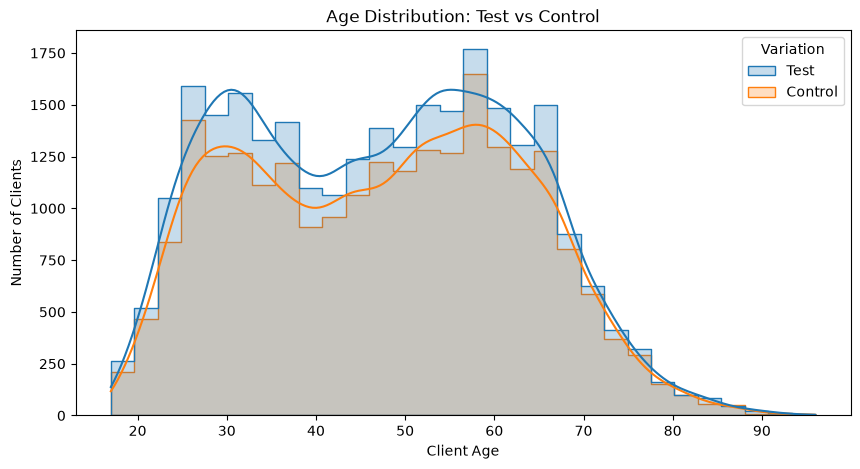

In [30]:
#Histogram
plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="clnt_age",
    hue="Variation",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Age Distribution: Test vs Control")
plt.xlabel("Client Age")
plt.ylabel("Number of Clients")

plt.show()

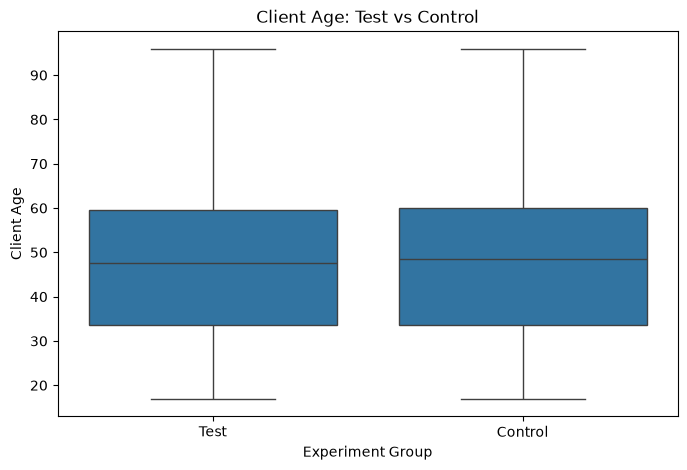

In [31]:
#Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=ab_clients_df,
    x="Variation",
    y="clnt_age"
)

plt.title("Client Age: Test vs Control")
plt.xlabel("Experiment Group")
plt.ylabel("Client Age")

plt.show()

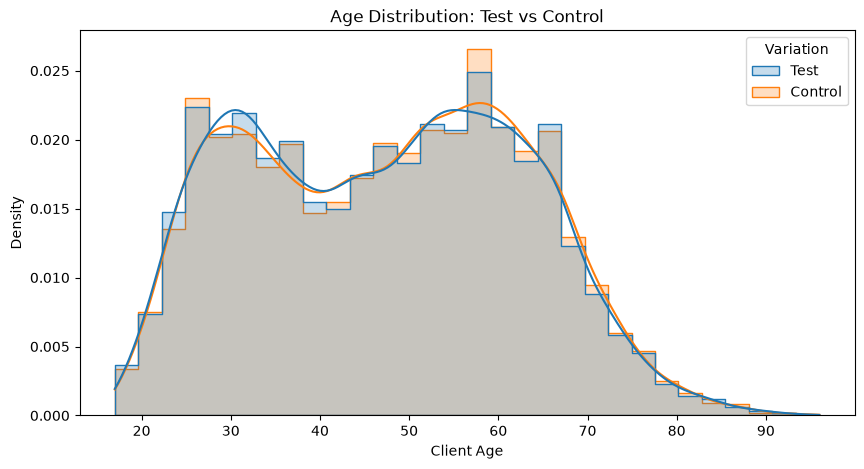

In [32]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="clnt_age",
    hue="Variation",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Age Distribution: Test vs Control")
plt.xlabel("Client Age")
plt.ylabel("Density")

plt.show()

In [33]:
### Age Distribution: Test vs Control

#The age distributions of the Test and Control groups show substantial overlap.

#The Test group has a mean age of approximately 47.16 years and a median age of 47.5 years, compared with a mean of approximately 47.50 years and a median of 48.5 years for the Control group.

#The boxplots show similar medians, interquartile ranges, and overall spreads. The distribution plots also show similar age patterns across the two experimental groups.

#Based on the descriptive statistics and visual evidence, there is no substantial age imbalance between the Test and Control groups. Statistical testing will be used to determine whether the small observed difference is statistically meaningful.

In [34]:
#check numerical outliers 
q1_age = ab_clients_df["clnt_age"].quantile(0.25)
q3_age = ab_clients_df["clnt_age"].quantile(0.75)

iqr_age = q3_age - q1_age

lower_age = q1_age - 1.5 * iqr_age
upper_age = q3_age + 1.5 * iqr_age

print("Q1:", q1_age)
print("Q3:", q3_age)
print("IQR:", iqr_age)
print("Lower bound:", lower_age)
print("Upper bound:", upper_age)

Q1: 33.5
Q3: 59.5
IQR: 26.0
Lower bound: -5.5
Upper bound: 98.5


In [35]:
age_outliers = ab_clients_df[
    (ab_clients_df["clnt_age"] < lower_age)
    | (ab_clients_df["clnt_age"] > upper_age)
]

print("Age outliers:", len(age_outliers))

Age outliers: 0


In [36]:
### Age Outlier Check

#The IQR method was used to identify potential outliers in client age.

#The lower bound was -5.5 years and the upper bound was 98.5 years. All observed client ages fell within these boundaries, resulting in zero age outliers.

#Therefore, no client records will be removed based on age outliers.

In [37]:
#Check the age distribution
#Calculate skewness and kurtosis
age_skewness = ab_clients_df["clnt_age"].skew()
age_kurtosis = ab_clients_df["clnt_age"].kurt()

print("Age skewness:", round(age_skewness, 3))
print("Age kurtosis:", round(age_kurtosis, 3))

Age skewness: 0.08
Age kurtosis: -0.947


In [38]:
from scipy import stats

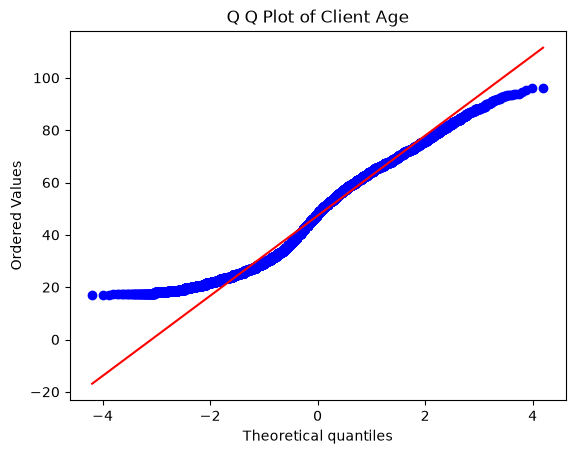

In [39]:
age_data = ab_clients_df["clnt_age"].dropna()

stats.probplot(
    age_data,
    dist="norm",
    plot=plt
)

plt.title("Q Q Plot of Client Age")
plt.show()

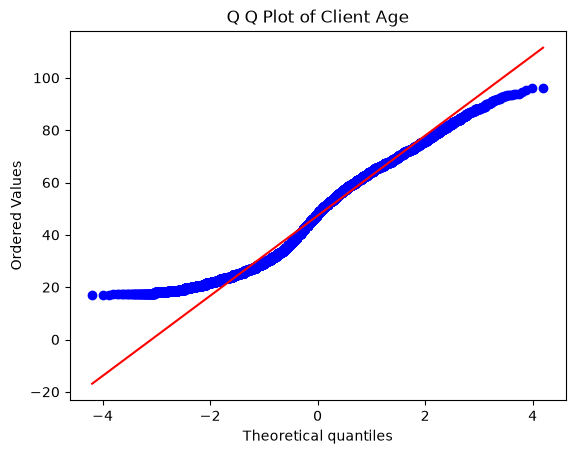

In [40]:
age_data = ab_clients_df["clnt_age"].dropna()

stats.probplot(
    age_data,
    dist="norm",
    plot=plt
)

plt.title("Q Q Plot of Client Age")
plt.show()

In [41]:
### Age Distribution Assessment

#Client age has a skewness of 0.080, indicating that the distribution is approximately symmetric.

#However, the kurtosis of -0.947 indicates a flatter distribution than the normal distribution. The Q Q plot also shows systematic departures from the theoretical normal reference line, particularly toward the tails.

#Therefore, although client age is approximately symmetric, the distribution should not be considered normally distributed.

#No age outliers were identified using the IQR method.


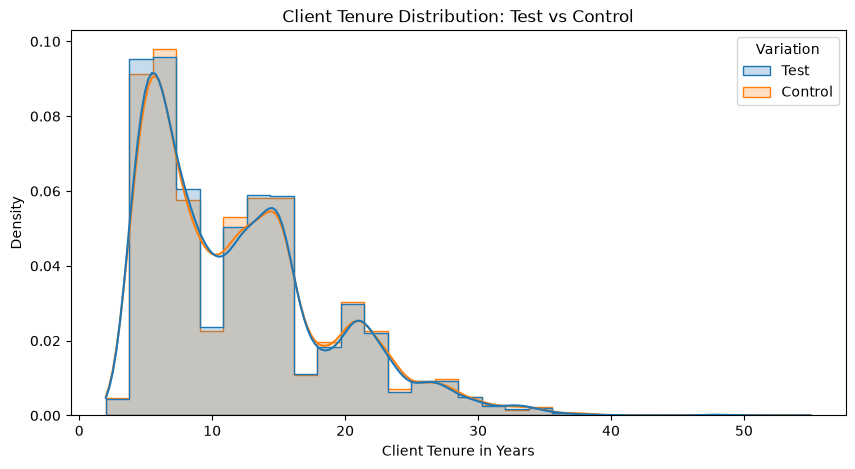

In [42]:
###tenure
plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="clnt_tenure_yr",
    hue="Variation",
    bins=30,
    kde=True,
    element="step",
    stat="density",
    common_norm=False
)

plt.title("Client Tenure Distribution: Test vs Control")
plt.xlabel("Client Tenure in Years")
plt.ylabel("Density")

plt.show()

In [43]:
### Client Tenure Distribution

#The Test and Control groups show very similar client tenure distributions, with substantial overlap across nearly the entire range.

#The Control group has an average tenure of approximately 12.09 years compared with 11.98 years for the Test group. Both groups have a median tenure of 11 years.

#The tenure distribution is right skewed, with most clients concentrated at lower to moderate tenure levels and a smaller number of clients having substantially longer relationships with Vanguard.

#Based on the descriptive statistics and visualization, there is no substantial difference in client tenure between the Test and Control groups.

In [44]:
#tenure outlier
q1_tenure = ab_clients_df["clnt_tenure_yr"].quantile(0.25)
q3_tenure = ab_clients_df["clnt_tenure_yr"].quantile(0.75)

iqr_tenure = q3_tenure - q1_tenure

lower_tenure = q1_tenure - 1.5 * iqr_tenure
upper_tenure = q3_tenure + 1.5 * iqr_tenure

print("Q1:", q1_tenure)
print("Q3:", q3_tenure)
print("IQR:", iqr_tenure)
print("Lower bound:", lower_tenure)
print("Upper bound:", upper_tenure)

Q1: 6.0
Q3: 16.0
IQR: 10.0
Lower bound: -9.0
Upper bound: 31.0


In [45]:
tenure_outliers = ab_clients_df[
    (ab_clients_df["clnt_tenure_yr"] < lower_tenure)
    | (ab_clients_df["clnt_tenure_yr"] > upper_tenure)
]

print("Tenure outliers:", len(tenure_outliers))

print(
    "Percentage:",
    round(
        len(tenure_outliers)
        / ab_clients_df["clnt_tenure_yr"].notna().sum()
        * 100,
        2
    ),
    "%"
)

Tenure outliers: 599
Percentage: 1.19 %


In [46]:
### Client Tenure Outlier Assessment

#Using the IQR method, the lower tenure boundary was -9 years and the upper boundary was 31 years.

#A total of 599 clients, approximately 1.19% of the experimental population with recorded tenure, were identified as statistical outliers above the upper boundary.

#These observations will be retained. Long client tenure is plausible and the IQR method identifies unusual values rather than necessarily incorrect values. There is currently no evidence that these records represent data errors.

#Therefore, tenure outliers are retained for the analysis.

In [47]:
tenure_outliers["Variation"].value_counts()

Variation
Test       325
Control    274
Name: count, dtype: int64

In [48]:
tenure_outlier_rates = (
    tenure_outliers["Variation"].value_counts()
    / ab_clients_df["Variation"].value_counts()
    * 100
)

tenure_outlier_rates

Variation
Test       1.205132
Control    1.164372
Name: count, dtype: float64

In [49]:
### Tenure Outliers by Experimental Group

#The tenure outliers are similarly distributed between the experimental groups.

#Approximately 1.21% of Test clients and 1.16% of Control clients were identified as tenure outliers using the IQR method.

#The difference is very small, providing no descriptive evidence that unusually long tenure is concentrated in either experimental group.

#The outliers will therefore be retained because they represent plausible long term client relationships and do not appear to create a meaningful imbalance between Test and Control.

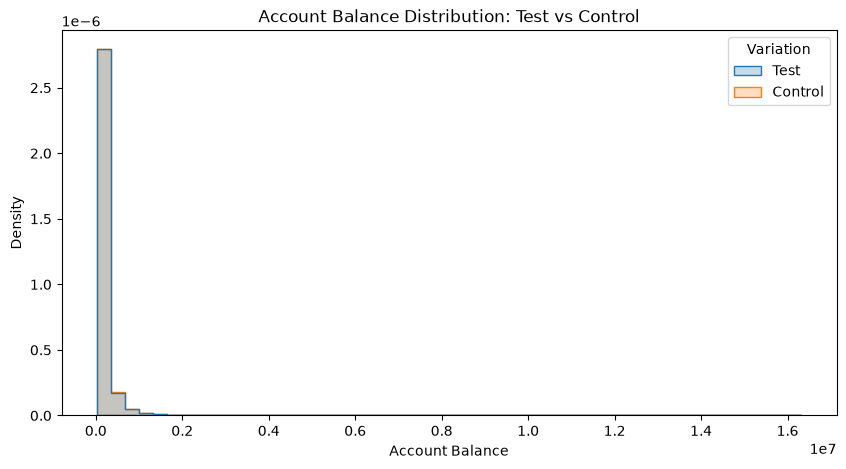

In [50]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=ab_clients_df,
    x="bal",
    hue="Variation",
    bins=50,
    stat="density",
    common_norm=False,
    element="step"
)

plt.title("Account Balance Distribution: Test vs Control")
plt.xlabel("Account Balance")
plt.ylabel("Density")

plt.show()

In [51]:
### Account Balance Distribution

#Account balance is strongly right skewed. Most clients are concentrated at substantially lower balance levels, while a relatively small number of clients have very high balances extending into the millions.

#These high balance observations stretch the horizontal scale of the distribution and cause most observations to appear compressed toward the lower end.

#The Control group has a mean balance of approximately $150,147 and a median balance of approximately $66,024. The Test group has a mean balance of approximately $148,963 and a median balance of approximately $65,468.

#The large difference between the mean and median within both groups confirms that account balance is influenced by high value observations. Therefore, the median should be considered alongside the mean when comparing the experimental groups.

#Despite the skewed distribution, the Test and Control groups show similar mean and median balances.

In [52]:
#calculate specifically the 50,500 experimental clients, because of the Test versus Control concerns.
q1_balance = ab_clients_df["bal"].quantile(0.25)
q3_balance = ab_clients_df["bal"].quantile(0.75)

iqr_balance = q3_balance - q1_balance

lower_balance = q1_balance - 1.5 * iqr_balance
upper_balance = q3_balance + 1.5 * iqr_balance

print("Q1:", q1_balance)
print("Q3:", q3_balance)
print("IQR:", iqr_balance)
print("Lower bound:", lower_balance)
print("Upper bound:", upper_balance)

Q1: 39878.4075
Q3: 139956.54499999998
IQR: 100078.13749999998
Lower bound: -110238.79874999999
Upper bound: 290073.75125


In [53]:
balance_outliers = ab_clients_df[
    (ab_clients_df["bal"] < lower_balance)
    | (ab_clients_df["bal"] > upper_balance)
]

print("Balance outliers:", len(balance_outliers))

print(
    "Percentage:",
    round(
        len(balance_outliers)
        / ab_clients_df["bal"].notna().sum()
        * 100,
        2
    ),
    "%"
)

Balance outliers: 5728
Percentage: 11.35 %


In [54]:
balance_outlier_rates = (
    balance_outliers["Variation"].value_counts()
    / ab_clients_df["Variation"].value_counts()
    * 100
)

balance_outlier_rates

Variation
Test       11.146544
Control    11.567228
Name: count, dtype: float64

In [55]:
### Account Balance Outlier Assessment

#Using the IQR method, account balances above approximately $290,074 were identified as statistical outliers.

#A total of 5,728 experimental clients, approximately 11.35% of clients with recorded balances, were identified as balance outliers.

#These observations will be retained. High account balances are plausible within an investment management context and should not automatically be treated as data errors. Removing them could also exclude an important high value client segment.

#The outliers are similarly represented across the experimental groups. Approximately 11.15% of Test clients and 11.57% of Control clients were identified as balance outliers.

#Therefore, there is no substantial descriptive evidence that high balance clients are disproportionately concentrated in either experimental group. Because the balance distribution is strongly right skewed, both median and mean balances will be considered when comparing the groups.

In [56]:
###Number of Accounts
#Compare the number of accounts held by Test and Control clients.
# Number of accounts by experiment group

account_summary = (
    ab_clients_df
    .groupby("Variation")["num_accts"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

account_summary

,count,mean,median,std,min,max
Variation,,,,,,
Control,23527,2.259914,2.0,0.538559,2.0,7.0
Test,26961,2.249917,2.0,0.529335,1.0,7.0


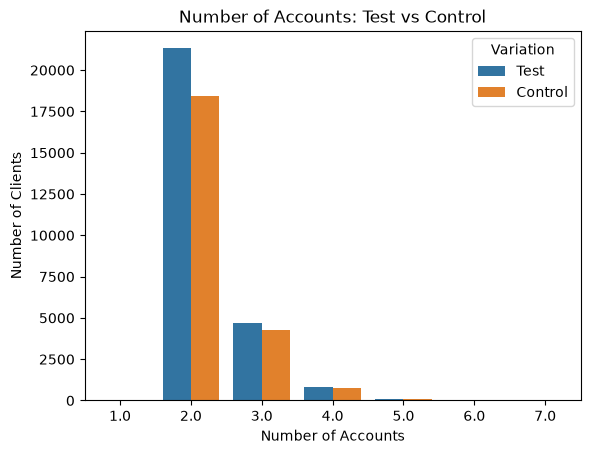

In [57]:
# Compare number of accounts between Test and Control

sns.countplot(
    data=ab_clients_df,
    x="num_accts",
    hue="Variation"
)

plt.title("Number of Accounts: Test vs Control")
plt.xlabel("Number of Accounts")
plt.ylabel("Number of Clients")

plt.show()

In [58]:
# Percentage distribution of number of accounts by group

account_distribution = pd.crosstab(
    ab_clients_df["num_accts"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

account_distribution.round(2)

Variation,Control,Test
num_accts,,
1.0,0.00,0.00
2.0,78.25,79.04
3.0,18.07,17.42
4.0,3.17,3.12
5.0,0.46,0.36
6.0,0.04,0.05
7.0,0.01,0.01


In [59]:
ab_clients_df[
    ab_clients_df["num_accts"] == 1
]["Variation"].value_counts()

Variation
Test    1
Name: count, dtype: int64

In [60]:
### Number of Accounts: Test vs Control

#The number of accounts held by clients is very similar between the Test and Control groups.

#The Control group has an average of approximately 2.26 accounts, while the Test group has an average of approximately 2.25 accounts. Both groups have a median of 2 accounts.

#Approximately 78.25% of Control clients and 79.04% of Test clients hold 2 accounts. The proportions of clients holding 3, 4, 5, 6, or 7 accounts are also very similar between the groups.

#Based on the descriptive statistics and percentage distributions, there is no meaningful imbalance in the number of accounts between Test and Control.

In [61]:
###Calls in the previous six months
#whether one group historically contacted Vanguard more often before the experiment.
calls_summary = (
    ab_clients_df
    .groupby("Variation")["calls_6_mnth"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

calls_summary

,count,mean,median,std,min,max
Variation,,,,,,
Control,23527,3.129213,3.0,2.184502,0.0,6.0
Test,26961,3.061941,3.0,2.190590,0.0,6.0


In [62]:
calls_distribution = pd.crosstab(
    ab_clients_df["calls_6_mnth"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

calls_distribution.round(2)

Variation,Control,Test
calls_6_mnth,,
0.0,14.84,15.73
1.0,15.27,16.01
2.0,14.67,13.96
3.0,11.41,11.75
4.0,9.61,9.59
5.0,9.57,9.11
6.0,24.63,23.85


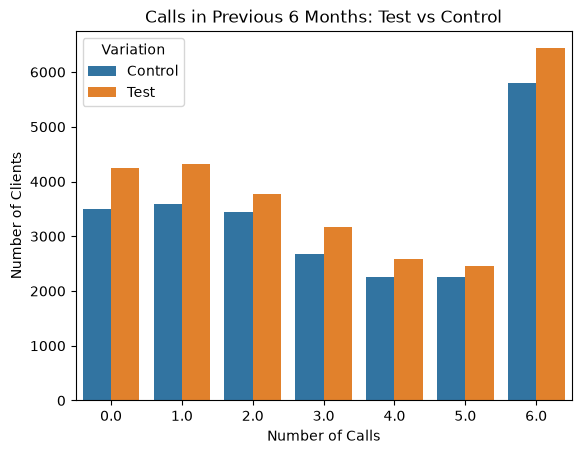

In [63]:
sns.countplot(
    data=ab_clients_df,
    x="calls_6_mnth",
    hue="Variation"
)

plt.title("Calls in Previous 6 Months: Test vs Control")
plt.xlabel("Number of Calls")
plt.ylabel("Number of Clients")

plt.show()

In [64]:
### Calls in the Previous Six Months

#The historical call activity of Test and Control clients is very similar.

#Control clients recorded an average of approximately 3.13 calls during the previous six months, while Test clients recorded approximately 3.06 calls. Both groups have a median of 3 calls.

#The percentage distributions across the different call frequencies are also similar. No single call category shows a substantial difference between the groups.

#Based on the descriptive statistics and percentage distributions, there is no meaningful evidence that one experimental group had substantially greater prior telephone engagement with Vanguard.

In [65]:
logons_summary = (
    ab_clients_df
    .groupby("Variation")["logons_6_mnth"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

logons_summary

,count,mean,median,std,min,max
Variation,,,,,,
Control,23527,6.166277,6.0,2.173014,3.0,9.0
Test,26961,6.101851,6.0,2.177119,3.0,9.0


In [67]:
#Percentage distribution
logons_distribution = pd.crosstab(
    ab_clients_df["logons_6_mnth"],
    ab_clients_df["Variation"],
    normalize="columns"
) * 100

logons_distribution.round(2)

Variation,Control,Test
logons_6_mnth,,
3.0,14.10,14.81
4.0,15.10,15.96
5.0,14.79,14.11
6.0,11.61,11.99
7.0,9.75,9.71
8.0,9.73,9.35
9.0,24.90,24.08


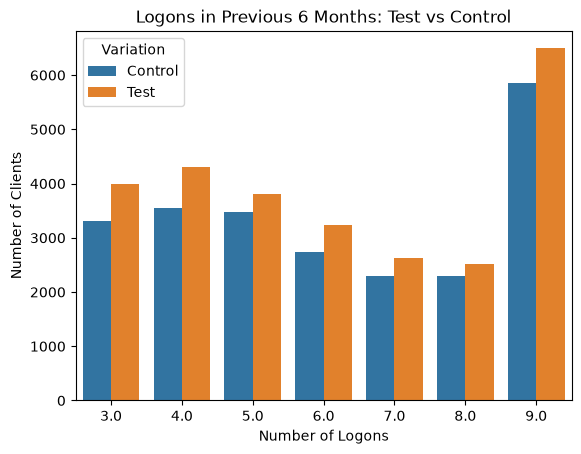

In [68]:
#Visualization
sns.countplot(
    data=ab_clients_df,
    x="logons_6_mnth",
    hue="Variation"
)

plt.title("Logons in Previous 6 Months: Test vs Control")
plt.xlabel("Number of Logons")
plt.ylabel("Number of Clients")

plt.show()

In [69]:
### Logons in the Previous Six Months

#Prior digital engagement is very similar between the Test and Control groups.

#Control clients recorded an average of approximately 6.17 logons during the previous six months, while Test clients recorded approximately 6.10 logons. Both groups have a median of 6 logons.

#The percentage distributions across logon frequencies are also very similar. No single logon category shows a substantial difference between Test and Control.

#Based on the descriptive statistics and percentage distributions, there is no meaningful evidence that one experimental group was substantially more digitally engaged before the A/B test.

In [ ]:
## Conclusion: Are Test and Control Comparable?

#The descriptive baseline assessment indicates that the Test and Control groups are broadly comparable across the available client characteristics.

#The groups show very similar age, tenure, number of accounts, account balance, historical call activity, historical logon activity, and recorded gender distributions.

#Potential outliers were examined for age, tenure, and account balance. Age contained no IQR outliers. Tenure and balance contained statistical outliers, but these observations were retained because they are plausible client characteristics and were similarly distributed between Test and Control.

#Historical engagement measures also show strong similarity. Test and Control clients recorded nearly identical call and logon patterns during the previous six months, suggesting that one group was not substantially more engaged with Vanguard before the experiment.

#Overall, the descriptive evidence suggests that the experimental groups were reasonably balanced before evaluating digital journey outcomes.

#This conclusion is descriptive. Formal statistical testing of group comparability and experimental outcomes will be conducted separately.